**Proyek Prediksi Customer Churn**

# **1. Business Understanding**
**Problem Statement**: Perusahaan telekomunikasi ingin mengetahui pelanggan mana yang berpotensi berhenti berlangganan (churn), agar bisa dilakukan retensi lebih awal.

**Goals**: Membangun model klasifikasi yang memprediksi apakah pelanggan akan churn berdasarkann data demografi, layanan, dan tagihan.

**Solution Statement**: Membandingkan beberapa algoritma seperti Logistic Regression,  Random Forest, XGBoost, dan memilih yang terbaik berdasarkan F1-Score.

**Langkah 1 - Memuat Dataset**

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Langkah 2 - Data Understanding**

In [43]:
df.info()
df.describe()
print("Jumlah Duplikat:", df.duplicated().sum())
print("Missing value:\n", df.isnull().sum())
print("\nDistribusi Target:")
print(df['Churn'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Langkah 3 - Visualisasi Distribusi Target dan Beberapa Fitur**

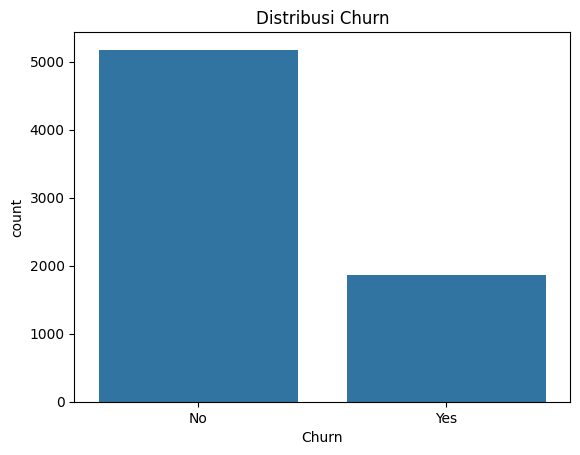

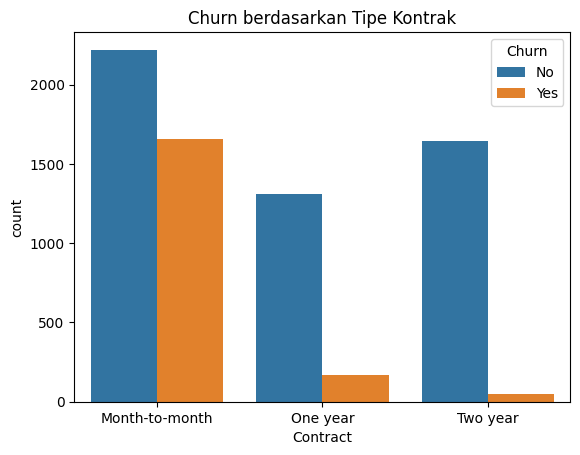

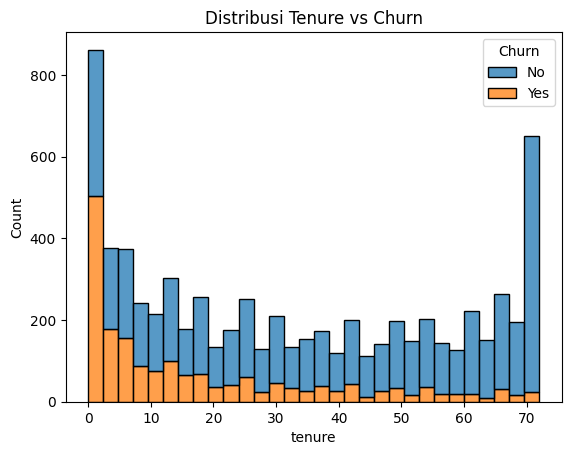

In [44]:
sns.countplot(x='Churn', data=df)
plt.title('Distribusi Churn')
plt.show()

# Hubungan Antara Churn dengan Kontrak
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn berdasarkan Tipe Kontrak')
plt.show()

# Hubungan Churn dengan Tenure
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Distribusi Tenure vs Churn')
plt.show()

**Insight**:Pelanggan dengan kontrak month-to-month dan tenure rendah lebih cendurung churn

# **2. Data Preparation**

**Langkah 1 - Cleaning**

In [45]:
# Kolom TotalCharges ada spasi kosong, kita harus konversi ke numerik
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Menghapus kolom customerID karena tidak relevan untuk model
df.drop('customerID', axis=1, inplace=True)

#Encode Target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


/tmp/ipykernel_2873/3026615846.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


**Langkah 2 - Encoding Fitur Kategorikal**

In [46]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='object').columns
le_dict = {}
for col in cat_cols:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  le_dict[col] = le

**Langkah 3 - Split Data**

In [47]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(5634, 19) (1409, 19)


**Langkah 4 - Scaling**

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **3. Modelling**
Kami membandingkan 3 algoritma: Logistic Regression (baseline), Random Forest, dan XGBoost

**Langkah 1 - Install dan Import XGBoost**

In [49]:
!pip install xgboost -q
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

**Langkah 2 - Training**

In [50]:
# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

# XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

# **4. Evaluation**

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate(model, X_test_data, y_test, name):
    y_pred = model.predict(X_test_data)
    print(f"=== {name} ===")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-Score :", f1_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print()

evaluate(lr, X_test_scaled, y_test, "Logistic Regression")
evaluate(rf, X_test, y_test, "Random Forest")
evaluate(xgb, X_test, y_test, "XGBoost")

=== Logistic Regression ===
Accuracy : 0.7991483321504613
Precision: 0.6426332288401254
Recall   : 0.5481283422459893
F1-Score : 0.5916305916305916
[[921 114]
 [169 205]]

=== Random Forest ===
Accuracy : 0.7920511000709723
Precision: 0.6372881355932203
Recall   : 0.5026737967914439
F1-Score : 0.5620328849028401
[[928 107]
 [186 188]]

=== XGBoost ===
Accuracy : 0.7785663591199432
Precision: 0.595679012345679
Recall   : 0.516042780748663
F1-Score : 0.5530085959885387
[[904 131]
 [181 193]]



In [55]:
# Berdasarkan F1-score, model terbaik dipilih (misal XGBoost)
best_model = lr
print("Model terpilih: Logistic Regression")

Model terpilih: Logistic Regression


Tulis di Markdown: bandingkan hasil ketiga model dalam tabel, jelaskan kenapa model terpilih jadi pilihan (F1-score tertinggi, dll). Catat angka hasil aslimu — nanti dipakai di README

# **5. Deployment**
Model disimpan dengan dibungkus dalam aplikasi web sederhana menggunakan streamlit

In [56]:
import joblib
joblib.dump(best_model, 'model_churn.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_dict, 'label_encoders.pkl')

# download ke komputer (jalankan di Colab)
from google.colab import files
files.download('model_churn.pkl')
files.download('scaler.pkl')
files.download('label_encoders.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>